In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
DATA_DIR = Path("../outputs/candidate_features")
OUTPUT_DIR = Path("../outputs/elasticnet_candidate_features")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEEPSEEK_FILE = DATA_DIR / "candidate_features_deepseek.csv"
GEMMA_FILE = DATA_DIR / "candidate_features_gemma.csv"

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Data directory: C:\Users\franc\OneDrive\Geop-Model\outputs\candidate_features
Output directory: C:\Users\franc\OneDrive\Geop-Model\outputs\elasticnet_candidate_features


In [3]:
deepseek = pd.read_csv(
    DEEPSEEK_FILE,
    parse_dates=["observation_date"]
)

gemma = pd.read_csv(
    GEMMA_FILE,
    parse_dates=["observation_date"]
)

print("DeepSeek:", deepseek.shape)
print("Gemma:", gemma.shape)

DeepSeek: (982, 126)
Gemma: (982, 126)


In [4]:
TARGET = "DEXUSEU_logreturn"

print("DeepSeek shape:", deepseek.shape)
print("Gemma shape:", gemma.shape)

print(
    "\nIdentical dates:",
    deepseek["observation_date"].equals(
        gemma["observation_date"]
    )
)

print(
    "Identical current returns:",
    np.allclose(
        deepseek[TARGET],
        gemma[TARGET]
    )
)

print(
    "\nDeepSeek missing values:",
    deepseek.isna().sum().sum()
)

print(
    "Gemma missing values:",
    gemma.isna().sum().sum()
)

print(
    "\nDate range:",
    deepseek["observation_date"].min(),
    "to",
    deepseek["observation_date"].max()
)

DeepSeek shape: (982, 126)
Gemma shape: (982, 126)

Identical dates: True
Identical current returns: True

DeepSeek missing values: 0
Gemma missing values: 0

Date range: 2017-01-17 00:00:00 to 2021-01-08 00:00:00


In [5]:
# Create next-period EUR/USD return target

deepseek["target_next_return"] = (
    deepseek[TARGET].shift(-1)
)

gemma["target_next_return"] = (
    gemma[TARGET].shift(-1)
)

# Final observation has no t+1 target
deepseek_model = (
    deepseek
    .dropna(subset=["target_next_return"])
    .copy()
    .reset_index(drop=True)
)

gemma_model = (
    gemma
    .dropna(subset=["target_next_return"])
    .copy()
    .reset_index(drop=True)
)

# Same candidate-feature universe as LASSO and Ridge
FEATURE_COLS = [
    col
    for col in deepseek_model.columns
    if col not in [
        "observation_date",
        TARGET,
        "target_next_return"
    ]
]

X_deepseek = deepseek_model[FEATURE_COLS].copy()
X_gemma = gemma_model[FEATURE_COLS].copy()

y = deepseek_model["target_next_return"].copy()
dates = deepseek_model["observation_date"].copy()

print("Observations:", len(y))
print("Number of predictors:", len(FEATURE_COLS))

print("DeepSeek X:", X_deepseek.shape)
print("Gemma X:", X_gemma.shape)

print(
    "Targets identical:",
    np.allclose(
        deepseek_model["target_next_return"],
        gemma_model["target_next_return"]
    )
)

Observations: 981
Number of predictors: 124
DeepSeek X: (981, 124)
Gemma X: (981, 124)
Targets identical: True


C:\Users\franc\AppData\Local\Temp\ipykernel_7932\1334797989.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  deepseek["target_next_return"] = (
C:\Users\franc\AppData\Local\Temp\ipykernel_7932\1334797989.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gemma["target_next_return"] = (


In [6]:
# Chronological 80/20 train-test split

split_idx = int(0.80 * len(y))

X_train_deepseek = X_deepseek.iloc[:split_idx].copy()
X_test_deepseek = X_deepseek.iloc[split_idx:].copy()

X_train_gemma = X_gemma.iloc[:split_idx].copy()
X_test_gemma = X_gemma.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

dates_train = dates.iloc[:split_idx].copy()
dates_test = dates.iloc[split_idx:].copy()

print("Training observations:", len(y_train))
print("Test observations:", len(y_test))

print(
    "\nTraining period:",
    dates_train.iloc[0],
    "to",
    dates_train.iloc[-1]
)

print(
    "Test period:",
    dates_test.iloc[0],
    "to",
    dates_test.iloc[-1]
)

Training observations: 784
Test observations: 197

Training period: 2017-01-17 00:00:00 to 2020-03-20 00:00:00
Test period: 2020-03-23 00:00:00 to 2021-01-06 00:00:00


In [7]:
# Time-series cross-validation within training sample

tscv = TimeSeriesSplit(n_splits=5)

print("Number of CV splits:", tscv.get_n_splits())

for i, (train_idx, val_idx) in enumerate(
    tscv.split(X_train_deepseek),
    start=1
):
    print(
        f"Fold {i}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}"
    )

Number of CV splits: 5
Fold 1: train=134, validation=130
Fold 2: train=264, validation=130
Fold 3: train=394, validation=130
Fold 4: train=524, validation=130
Fold 5: train=654, validation=130


In [8]:
# Leakage-safe Elastic Net pipeline

elasticnet_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "elasticnet",
        ElasticNet(
            max_iter=100000
        )
    )
])

print(elasticnet_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('elasticnet', ElasticNet(max_iter=100000))])


In [9]:
# Elastic Net hyperparameter grids

l1_ratios = [
    0.1,
    0.5,
    0.7,
    0.9,
    0.95,
    0.99,
    1.0
]

alphas = np.logspace(
    -6,
    -1,
    100
)

print("l1_ratio values:")
print(l1_ratios)

print("\nNumber of alpha values:", len(alphas))
print("Minimum alpha:", alphas.min())
print("Maximum alpha:", alphas.max())

l1_ratio values:
[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

Number of alpha values: 100
Minimum alpha: 1e-06
Maximum alpha: 0.1


In [10]:
# DeepSeek Elastic Net tuning

elasticnet_pipeline_deepseek = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "elasticnet",
        ElasticNet(
            max_iter=100000
        )
    )
])

param_grid = {
    "elasticnet__alpha": alphas,
    "elasticnet__l1_ratio": l1_ratios
}

elasticnet_search_deepseek = GridSearchCV(
    estimator=elasticnet_pipeline_deepseek,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    refit=True,
    n_jobs=-1
)

elasticnet_search_deepseek.fit(
    X_train_deepseek,
    y_train
)

best_alpha_deepseek = (
    elasticnet_search_deepseek
    .best_params_["elasticnet__alpha"]
)

best_l1_ratio_deepseek = (
    elasticnet_search_deepseek
    .best_params_["elasticnet__l1_ratio"]
)

best_cv_mse_deepseek = (
    -elasticnet_search_deepseek.best_score_
)

print("DEEPSEEK")
print("Best alpha:", best_alpha_deepseek)
print("Best l1_ratio:", best_l1_ratio_deepseek)
print("Best mean CV MSE:", best_cv_mse_deepseek)

DEEPSEEK
Best alpha: 0.0008497534359086438
Best l1_ratio: 0.99
Best mean CV MSE: 1.57711241805162e-05


In [11]:
# Gemma Elastic Net tuning

elasticnet_pipeline_gemma = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "elasticnet",
        ElasticNet(
            max_iter=100000
        )
    )
])

elasticnet_search_gemma = GridSearchCV(
    estimator=elasticnet_pipeline_gemma,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    refit=True,
    n_jobs=-1
)

elasticnet_search_gemma.fit(
    X_train_gemma,
    y_train
)

best_alpha_gemma = (
    elasticnet_search_gemma
    .best_params_["elasticnet__alpha"]
)

best_l1_ratio_gemma = (
    elasticnet_search_gemma
    .best_params_["elasticnet__l1_ratio"]
)

best_cv_mse_gemma = (
    -elasticnet_search_gemma.best_score_
)

print("GEMMA")
print("Best alpha:", best_alpha_gemma)
print("Best l1_ratio:", best_l1_ratio_gemma)
print("Best mean CV MSE:", best_cv_mse_gemma)

GEMMA
Best alpha: 0.0008497534359086438
Best l1_ratio: 0.95
Best mean CV MSE: 1.57711241805162e-05


In [12]:
# Extract best fitted Elastic Net models

best_model_deepseek = (
    elasticnet_search_deepseek.best_estimator_
)

best_model_gemma = (
    elasticnet_search_gemma.best_estimator_
)

elasticnet_deepseek = (
    best_model_deepseek.named_steps["elasticnet"]
)

elasticnet_gemma = (
    best_model_gemma.named_steps["elasticnet"]
)

print("DEEPSEEK")
print(
    "Non-zero coefficients:",
    np.count_nonzero(
        elasticnet_deepseek.coef_
    )
)

print("\nGEMMA")
print(
    "Non-zero coefficients:",
    np.count_nonzero(
        elasticnet_gemma.coef_
    )
)

DEEPSEEK
Non-zero coefficients: 0

GEMMA
Non-zero coefficients: 0


In [13]:
# Elastic Net coefficient path — DeepSeek

alpha_path = np.logspace(-6, -3, 100)

path_rows_deepseek = []

for alpha in alpha_path:

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        (
            "elasticnet",
            ElasticNet(
                alpha=alpha,
                l1_ratio=best_l1_ratio_deepseek,
                max_iter=100000
            )
        )
    ])

    pipe.fit(
        X_train_deepseek,
        y_train
    )

    coefs = pipe.named_steps["elasticnet"].coef_

    row = {"alpha": alpha}

    for feature, coef in zip(
        FEATURE_COLS,
        coefs
    ):
        row[feature] = coef

    path_rows_deepseek.append(row)

elasticnet_path_deepseek = pd.DataFrame(
    path_rows_deepseek
)

print("DeepSeek path created:", elasticnet_path_deepseek.shape)

DeepSeek path created: (100, 125)


In [14]:
# Elastic Net coefficient path — Gemma

path_rows_gemma = []

for alpha in alpha_path:

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        (
            "elasticnet",
            ElasticNet(
                alpha=alpha,
                l1_ratio=best_l1_ratio_gemma,
                max_iter=100000
            )
        )
    ])

    pipe.fit(
        X_train_gemma,
        y_train
    )

    coefs = pipe.named_steps["elasticnet"].coef_

    row = {"alpha": alpha}

    for feature, coef in zip(
        FEATURE_COLS,
        coefs
    ):
        row[feature] = coef

    path_rows_gemma.append(row)

elasticnet_path_gemma = pd.DataFrame(
    path_rows_gemma
)

print("Gemma path created:", elasticnet_path_gemma.shape)

Gemma path created: (100, 125)


In [15]:
def elasticnet_survival_table(
    path_df,
    feature_cols
):
    rows = []

    for feature in feature_cols:

        nonzero = path_df[
            ~np.isclose(
                path_df[feature],
                0.0
            )
        ]

        if len(nonzero) > 0:
            max_alpha_nonzero = (
                nonzero["alpha"].max()
            )
        else:
            max_alpha_nonzero = np.nan

        rows.append({
            "feature": feature,
            "max_alpha_nonzero": max_alpha_nonzero
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "max_alpha_nonzero",
            ascending=False
        )
        .reset_index(drop=True)
    )


elasticnet_survival_deepseek = (
    elasticnet_survival_table(
        elasticnet_path_deepseek,
        FEATURE_COLS
    )
)

elasticnet_survival_gemma = (
    elasticnet_survival_table(
        elasticnet_path_gemma,
        FEATURE_COLS
    )
)

print("DEEPSEEK — top 25 surviving features")
display(
    elasticnet_survival_deepseek.head(25)
)

print("\nGEMMA — top 25 surviving features")
display(
    elasticnet_survival_gemma.head(25)
)

DEEPSEEK — top 25 surviving features


,feature,max_alpha_nonzero
0,VIXCLS_lag2,0.000433
1,DGS2_diff,0.000404
2,USEPUINDXD_lag2,0.000376
3,VIXCLS_diff,0.000351
4,sanctions_mean_lag2,0.000351
5,trade_mean_diff,0.000327
6,fed_pressure_mean_ma10,0.000327
7,VIXCLS_diff_lag2,0.000327
8,sanctions_max_ma10,0.000285
9,DGS2_diff_lag5,0.000266



GEMMA — top 25 surviving features


,feature,max_alpha_nonzero
0,VIXCLS_lag2,0.000464
1,DGS2_diff,0.000433
2,USEPUINDXD_lag2,0.000404
3,VIXCLS_diff,0.000376
4,sanctions_sum_ma10,0.000376
5,VIXCLS_diff_lag2,0.000327
6,fed_pressure_mean_ma10,0.000327
7,DGS2_diff_lag5,0.000266
8,DGS2_diff_lag1,0.000266
9,sanctions_sum,0.000215


In [16]:
def feature_source(feature):
    if feature.startswith("DEXUSEU"):
        return "EURUSD"
    elif feature.startswith(
        ("DGS2", "USEPUINDXD", "VIXCLS")
    ):
        return "Macro"
    else:
        return "Geopolitical"


def geopolitical_index(feature):
    if feature.startswith("trade"):
        return "Trade"
    elif feature.startswith("sanctions"):
        return "Sanctions"
    elif feature.startswith("fed_pressure"):
        return "Fed Pressure"
    else:
        return np.nan


def geopolitical_representation(feature):
    if "_ma10" in feature:
        return "MA10"
    elif "_ma5" in feature:
        return "MA5"
    elif "_ma3" in feature:
        return "MA3"
    elif "_diff" in feature:
        return "Difference"
    elif "_lag" in feature:
        return "Lag"
    elif "_sum" in feature:
        return "Sum"
    elif "_mean" in feature:
        return "Mean"
    elif "_max" in feature:
        return "Max"
    else:
        return "Other"


for table in [
    elasticnet_survival_deepseek,
    elasticnet_survival_gemma
]:
    table["source"] = (
        table["feature"].apply(
            feature_source
        )
    )

    table["geopolitical_index"] = (
        table["feature"].apply(
            geopolitical_index
        )
    )

    table["representation"] = (
        table["feature"].apply(
            geopolitical_representation
        )
    )

In [17]:
# Keep geopolitical candidates only

elasticnet_geop_deepseek = (
    elasticnet_survival_deepseek[
        elasticnet_survival_deepseek["source"]
        == "Geopolitical"
    ]
    .copy()
)

elasticnet_geop_gemma = (
    elasticnet_survival_gemma[
        elasticnet_survival_gemma["source"]
        == "Geopolitical"
    ]
    .copy()
)

print(
    "DeepSeek geopolitical candidates:",
    len(elasticnet_geop_deepseek)
)

print(
    "Gemma geopolitical candidates:",
    len(elasticnet_geop_gemma)
)

DeepSeek geopolitical candidates: 81
Gemma geopolitical candidates: 81


In [18]:
# Elastic Net survival by geopolitical representation

representation_survival_deepseek = (
    elasticnet_geop_deepseek
    .groupby("representation")["max_alpha_nonzero"]
    .agg(["mean", "median", "max", "count"])
    .sort_values("mean", ascending=False)
)

representation_survival_gemma = (
    elasticnet_geop_gemma
    .groupby("representation")["max_alpha_nonzero"]
    .agg(["mean", "median", "max", "count"])
    .sort_values("mean", ascending=False)
)

print("DEEPSEEK")
display(representation_survival_deepseek)

print("\nGEMMA")
display(representation_survival_gemma)

DEEPSEEK


,mean,median,max,count
representation,,,,
MA10,0.000096,0.000043,0.000327,9
Difference,0.000094,0.000050,0.000327,7
Lag,0.000061,0.000031,0.000351,33
Mean,0.000046,0.000027,0.000087,3
MA5,0.000029,0.000009,0.000100,9
Sum,0.000027,0.000027,0.000028,2
Max,0.000014,0.000011,0.000031,3
MA3,0.000006,0.000005,0.000012,5



GEMMA


,mean,median,max,count
representation,,,,
MA10,0.000121,0.000027,0.000376,7
Sum,0.000087,0.000028,0.000215,3
Difference,0.000073,0.000061,0.000201,7
Lag,0.000054,0.000042,0.000163,32
Max,0.000050,0.000050,0.000050,1
Mean,0.000050,0.000053,0.000087,3
MA5,0.000021,0.000019,0.000050,9
MA3,0.000018,0.000011,0.000046,4


In [19]:
# Elastic Net survival by representation and geopolitical index

index_rep_survival_deepseek = (
    elasticnet_geop_deepseek
    .groupby(
        ["representation", "geopolitical_index"]
    )["max_alpha_nonzero"]
    .mean()
    .unstack()
)

index_rep_survival_gemma = (
    elasticnet_geop_gemma
    .groupby(
        ["representation", "geopolitical_index"]
    )["max_alpha_nonzero"]
    .mean()
    .unstack()
)

print("DEEPSEEK")
display(index_rep_survival_deepseek)

print("\nGEMMA")
display(index_rep_survival_gemma)

DEEPSEEK


geopolitical_index,Fed Pressure,Sanctions,Trade
representation,,,
Difference,0.000033,0.000071,0.000189
Lag,0.000045,0.000070,0.000067
MA10,0.000114,0.000098,0.000077
MA3,0.000006,0.000002,0.000012
MA5,0.000029,0.000004,0.000053
Max,0.000011,0.000002,0.000031
Mean,0.000025,0.000087,0.000027
Sum,NaN,0.000028,0.000025



GEMMA


geopolitical_index,Fed Pressure,Sanctions,Trade
representation,,,
Difference,0.000087,0.000043,0.000098
Lag,0.000042,0.000057,0.000063
MA10,0.000172,0.000229,0.000015
MA3,0.000026,NaN,0.000010
MA5,0.000007,0.000028,0.000028
Max,NaN,NaN,0.000050
Mean,0.000009,0.000053,0.000087
Sum,0.000016,0.000215,0.000028


In [20]:
# MA10 survival detail

ma10_survival_deepseek = (
    elasticnet_geop_deepseek[
        elasticnet_geop_deepseek["representation"]
        == "MA10"
    ]
    .sort_values(
        "max_alpha_nonzero",
        ascending=False
    )
)

ma10_survival_gemma = (
    elasticnet_geop_gemma[
        elasticnet_geop_gemma["representation"]
        == "MA10"
    ]
    .sort_values(
        "max_alpha_nonzero",
        ascending=False
    )
)

print("DEEPSEEK — MA10")
display(
    ma10_survival_deepseek[
        [
            "feature",
            "max_alpha_nonzero",
            "geopolitical_index"
        ]
    ]
)

print("\nGEMMA — MA10")
display(
    ma10_survival_gemma[
        [
            "feature",
            "max_alpha_nonzero",
            "geopolitical_index"
        ]
    ]
)

DEEPSEEK — MA10


,feature,max_alpha_nonzero,geopolitical_index
6,fed_pressure_mean_ma10,0.000327,Fed Pressure
8,sanctions_max_ma10,0.000285,Sanctions
20,trade_sum_ma10,0.000123,Trade
38,trade_mean_ma10,0.000066,Trade
47,trade_max_ma10,0.000043,Trade
82,fed_pressure_sum_ma10,0.000009,Fed Pressure
90,sanctions_mean_ma10,0.000005,Sanctions
92,fed_pressure_max_ma10,0.000004,Fed Pressure
94,sanctions_sum_ma10,0.000004,Sanctions



GEMMA — MA10


,feature,max_alpha_nonzero,geopolitical_index
4,sanctions_sum_ma10,0.000376,Sanctions
6,fed_pressure_mean_ma10,0.000327,Fed Pressure
35,sanctions_mean_ma10,0.000081,Sanctions
58,trade_max_ma10,0.000027,Trade
68,fed_pressure_sum_ma10,0.000016,Fed Pressure
70,trade_mean_ma10,0.000013,Trade
83,trade_sum_ma10,0.000006,Trade
118,sanctions_max_ma10,NaN,Sanctions
123,fed_pressure_max_ma10,NaN,Fed Pressure


In [21]:
# Elastic Net test-set predictions

y_pred_elasticnet_deepseek = (
    best_model_deepseek.predict(
        X_test_deepseek
    )
)

y_pred_elasticnet_gemma = (
    best_model_gemma.predict(
        X_test_gemma
    )
)

# Benchmarks based only on training information
mean_forecast = np.repeat(
    y_train.mean(),
    len(y_test)
)

zero_forecast = np.zeros(
    len(y_test)
)

In [22]:
def evaluate_forecast(y_true, y_pred):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(
            y_true, y_pred
        ),
        "R2": r2_score(
            y_true, y_pred
        )
    }


elasticnet_results = pd.DataFrame({
    "DeepSeek_ElasticNet": evaluate_forecast(
        y_test,
        y_pred_elasticnet_deepseek
    ),
    "Gemma_ElasticNet": evaluate_forecast(
        y_test,
        y_pred_elasticnet_gemma
    ),
    "Mean_Benchmark": evaluate_forecast(
        y_test,
        mean_forecast
    ),
    "Zero_Benchmark": evaluate_forecast(
        y_test,
        zero_forecast
    )
}).T

display(elasticnet_results)

,RMSE,MAE,R2
DeepSeek_ElasticNet,0.004286,0.003365,-0.024624
Gemma_ElasticNet,0.004286,0.003365,-0.024624
Mean_Benchmark,0.004286,0.003365,-0.024624
Zero_Benchmark,0.004287,0.003366,-0.024999


In [23]:
elasticnet_summary = pd.DataFrame({
    "model": [
        "DeepSeek_ElasticNet",
        "Gemma_ElasticNet"
    ],
    "best_alpha": [
        best_alpha_deepseek,
        best_alpha_gemma
    ],
    "best_l1_ratio": [
        best_l1_ratio_deepseek,
        best_l1_ratio_gemma
    ],
    "cv_mse": [
        best_cv_mse_deepseek,
        best_cv_mse_gemma
    ],
    "n_candidate_features": [
        len(FEATURE_COLS),
        len(FEATURE_COLS)
    ],
    "n_selected_features": [
        np.count_nonzero(
            elasticnet_deepseek.coef_
        ),
        np.count_nonzero(
            elasticnet_gemma.coef_
        )
    ],
    "top_geopolitical_representation": [
        representation_survival_deepseek.index[0],
        representation_survival_gemma.index[0]
    ]
})

display(elasticnet_summary)

,model,best_alpha,best_l1_ratio,cv_mse,n_candidate_features,n_selected_features,top_geopolitical_representation
0,DeepSeek_ElasticNet,0.00085,0.99,0.000016,124,0,MA10
1,Gemma_ElasticNet,0.00085,0.95,0.000016,124,0,MA10


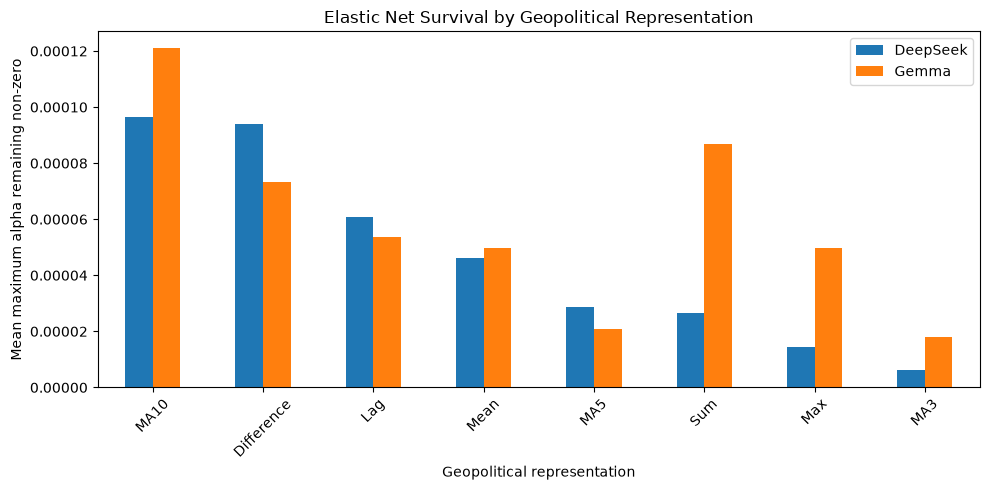

In [24]:
# Plot mean Elastic Net survival by geopolitical representation

representation_plot = pd.DataFrame({
    "DeepSeek": representation_survival_deepseek["mean"],
    "Gemma": representation_survival_gemma["mean"]
}).fillna(0)

representation_plot = representation_plot.sort_values(
    "DeepSeek",
    ascending=False
)

ax = representation_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_xlabel("Geopolitical representation")
ax.set_ylabel("Mean maximum alpha remaining non-zero")
ax.set_title(
    "Elastic Net Survival by Geopolitical Representation"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "elasticnet_geopolitical_representation_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Save Elastic Net outputs

elasticnet_results.to_csv(
    OUTPUT_DIR / "elasticnet_test_metrics.csv"
)

elasticnet_summary.to_csv(
    OUTPUT_DIR / "elasticnet_summary.csv",
    index=False
)

elasticnet_survival_deepseek.to_csv(
    OUTPUT_DIR / "elasticnet_survival_deepseek.csv",
    index=False
)

elasticnet_survival_gemma.to_csv(
    OUTPUT_DIR / "elasticnet_survival_gemma.csv",
    index=False
)

representation_survival_deepseek.to_csv(
    OUTPUT_DIR / "elasticnet_representation_survival_deepseek.csv"
)

representation_survival_gemma.to_csv(
    OUTPUT_DIR / "elasticnet_representation_survival_gemma.csv"
)

index_rep_survival_deepseek.to_csv(
    OUTPUT_DIR / "elasticnet_representation_by_index_deepseek.csv"
)

index_rep_survival_gemma.to_csv(
    OUTPUT_DIR / "elasticnet_representation_by_index_gemma.csv"
)

ma10_survival_deepseek.to_csv(
    OUTPUT_DIR / "elasticnet_ma10_survival_deepseek.csv",
    index=False
)

ma10_survival_gemma.to_csv(
    OUTPUT_DIR / "elasticnet_ma10_survival_gemma.csv",
    index=False
)

print("Elastic Net outputs saved to:")
print(OUTPUT_DIR.resolve())

Elastic Net outputs saved to:
C:\Users\franc\OneDrive\Geop-Model\outputs\elasticnet_candidate_features


In [26]:
print("=" * 60)
print("ELASTIC NET CANDIDATE-FEATURE ANALYSIS COMPLETE")
print("=" * 60)

print("\nDEEPSEEK")
print(f"Best alpha: {best_alpha_deepseek:.8f}")
print(f"Best l1 ratio: {best_l1_ratio_deepseek}")
print(
    "Selected features:",
    np.count_nonzero(elasticnet_deepseek.coef_),
    "/",
    len(FEATURE_COLS)
)
print(
    "Top geopolitical representation:",
    representation_survival_deepseek.index[0]
)
print(
    "Test RMSE:",
    elasticnet_results.loc[
        "DeepSeek_ElasticNet", "RMSE"
    ]
)

print("\nGEMMA")
print(f"Best alpha: {best_alpha_gemma:.8f}")
print(f"Best l1 ratio: {best_l1_ratio_gemma}")
print(
    "Selected features:",
    np.count_nonzero(elasticnet_gemma.coef_),
    "/",
    len(FEATURE_COLS)
)
print(
    "Top geopolitical representation:",
    representation_survival_gemma.index[0]
)
print(
    "Test RMSE:",
    elasticnet_results.loc[
        "Gemma_ElasticNet", "RMSE"
    ]
)

print("\nBENCHMARKS")
print(
    "Mean benchmark RMSE:",
    elasticnet_results.loc[
        "Mean_Benchmark", "RMSE"
    ]
)
print(
    "Zero benchmark RMSE:",
    elasticnet_results.loc[
        "Zero_Benchmark", "RMSE"
    ]
)

print("\nOutputs:")
print(OUTPUT_DIR.resolve())

ELASTIC NET CANDIDATE-FEATURE ANALYSIS COMPLETE

DEEPSEEK
Best alpha: 0.00084975
Best l1 ratio: 0.99
Selected features: 0 / 124
Top geopolitical representation: MA10
Test RMSE: 0.0042861051043039415

GEMMA
Best alpha: 0.00084975
Best l1 ratio: 0.95
Selected features: 0 / 124
Top geopolitical representation: MA10
Test RMSE: 0.0042861051043039415

BENCHMARKS
Mean benchmark RMSE: 0.0042861051043039415
Zero benchmark RMSE: 0.004286889580202056

Outputs:
C:\Users\franc\OneDrive\Geop-Model\outputs\elasticnet_candidate_features
